This codelab is largely based on [scikit-learn example code](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html?highlight=svc#sklearn.svm.SVC).

In [1]:
import matplotlib.pyplot as plt
from sklearn import svm

%matplotlib inline

# SVM

In [2]:
X = [[0, 0], [1, 1]]
y = [0, 1]
model = svm.SVC(gamma="auto")
model.fit(X, y)

SVC(gamma='auto')

## Prediction


In [3]:
model.predict([[0.2, 0.2], [-1.0, -1.0], [3.0, 3.0], [0.51, 0.51]])

array([0, 0, 1, 1])

## Support Vectors

We can retrieve the training examples used as support vectors

In [4]:
# get support vectors
print("support vectors: ", model.support_vectors_)

# get indices of support vectors
print("support index: ", model.support_)

# get number of support vectors for each class
print("#support by class : ", model.n_support_)

support vectors:  [[0. 0.]
 [1. 1.]]
support index:  [0 1]
#support by class :  [1 1]


## Finding the Separating Hyperplane

Here, we display the decision boundary of the trained SVM

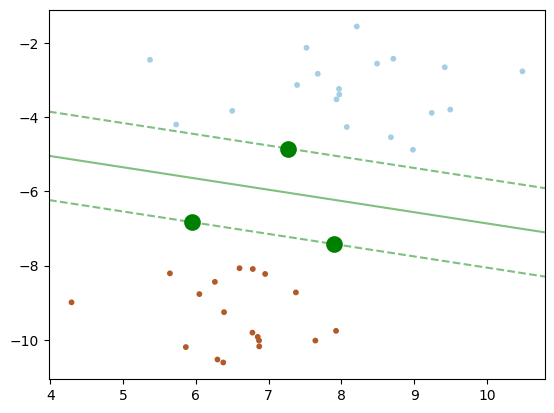

In [5]:
import numpy as np
from sklearn import svm
from sklearn.datasets import make_blobs

# Create 40 separable points of 2 classes
X, y = make_blobs(n_samples=40, centers=2, random_state=6)

# Create the model
model = svm.SVC(kernel="linear", C=1)
model.fit(X, y)

# Plot the 40 points
plt.scatter(X[:, 0], X[:, 1], c=y, s=10, cmap=plt.cm.Paired)

# Get x_max, x_min, y_max, y_min (useful for a nice plot)
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Use meshgrid
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model.decision_function(xy).reshape(XX.shape)

# Plot the contours where Z==-1, Z==0, Z==1
ax.contour(
  XX, YY, Z, colors="g", levels=[-1, 0, 1], alpha=0.5, linestyles=["--", "-", "--"]
)
# Plot the support vectors
ax.scatter(
  model.support_vectors_[:, 0],
  model.support_vectors_[:, 1],
  s=100,
  linewidth=2,
  facecolors="g",
)
plt.show()

# Finding the Separating Hyperplane With Imbalanced Classes

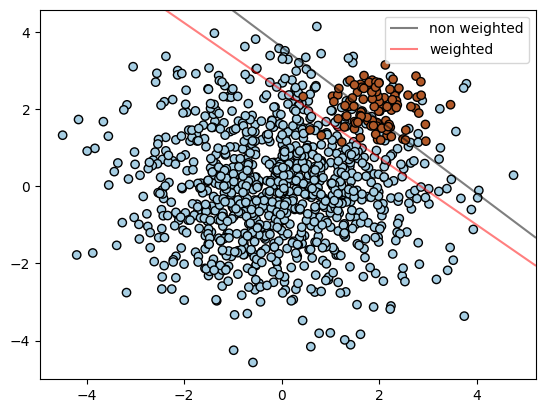

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import svm

# Create clusters of 1000 and 100 points
rng = np.random.RandomState(0)
n_samples_1 = 1000
n_samples_2 = 100
X = np.r_[1.5 * rng.randn(n_samples_1, 2), 0.5 * rng.randn(n_samples_2, 2) + [2, 2]]
y = [0] * (n_samples_1) + [1] * (n_samples_2)

# C=0.050000
C = 1

# Create the model without correction
model = svm.SVC(kernel="linear", C=C)
model.fit(X, y)

# The model that accounts for the proportion of each class
weigth_model = svm.SVC(kernel="linear", class_weight={0: 1, 1: 10}, C=C)
weigth_model.fit(X, y)

# Plot
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, edgecolors="k")

# Get x_max, x_min, y_max, y_min (useful for a nice plot)
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Use meshgrid
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# Predict on the whole grid with model
Z = model.decision_function(xy).reshape(XX.shape)

# Plot the contours of model where Z==0
a = ax.contour(XX, YY, Z, colors="k", levels=[0], alpha=0.5, linestyles=["-"])

# Predict on the whole grid with weigth_model
Z = weigth_model.decision_function(xy).reshape(XX.shape)

# Plot the contours of weigth_model where Z==0
b = ax.contour(XX, YY, Z, colors="r", levels=[0], alpha=0.5, linestyles=["-"])

# A legend never hurts
plt.legend(
  [a.legend_elements()[0][0], b.legend_elements()[0][0]],
  ["non weighted", "weighted"],
  loc="upper right",
)
plt.show()

#Non-Linear (Kernel) SVM

To make the task harder, we build a dataset from a XOR

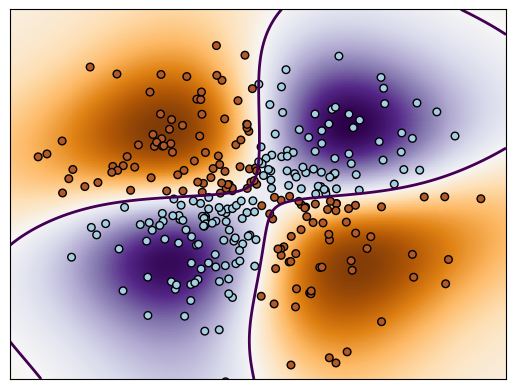

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import svm

np.random.seed(0)
X = np.random.randn(300, 2)
Y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0)

# Create the model (SVM uses an rbf kernel by default)
model = svm.SVC(gamma="auto", kernel="rbf")
model.fit(X, Y)

# The meshgrid
xx, yy = np.meshgrid(np.linspace(-3, 3, 500), np.linspace(-3, 3, 500))
Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# To display a nice color gradient
plt.imshow(
  Z,
  interpolation="nearest",
  extent=(xx.min(), xx.max(), yy.min(), yy.max()),
  aspect="auto",
  origin="lower",
  cmap=plt.cm.PuOr_r,
)
# The contour where Z==0
contours = plt.contour(xx, yy, Z, levels=[0], linewidths=2)
# The points
plt.scatter(X[:, 0], X[:, 1], s=30, c=Y, cmap=plt.cm.Paired, edgecolors="k")
plt.xticks(())
plt.yticks(())
plt.axis([-3, 3, -3, 3])
plt.show()

# Multi-class SVM

Comparison of 4 different linear SVM classifier instances on the iris dataset.
We only consider the first 2 features:

   * Sepal length
   * Sepal width

LinearSVC() and SVC(kernel='linear') get slightly different boundaries for these reasons:

   * LinearSVC minimizes the squared hinge loss while SVC minimizes the plain hinge loss.
   * LinearSVC uses the One-vs-All strategy while SVC uses One-vs-One.

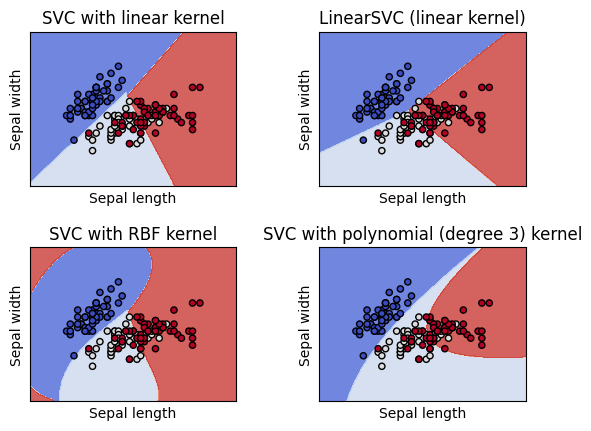

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, svm


def make_meshgrid(x, y, h=0.02):
  """Create a mesh of points to plot in

  Parameters
  ----------
  x: data to base x-axis meshgrid on
  y: data to base y-axis meshgrid on
  h: stepsize for meshgrid, optional

  Returns:
  -------
  xx, yy : ndarray
  """
  x_min, x_max = x.min() - 1, x.max() + 1
  y_min, y_max = y.min() - 1, y.max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
  return xx, yy


def plot_contours(ax, model, xx, yy, **params):
  """Plot the decision boundaries for a classifier.

  Parameters
  ----------
  ax: matplotlib axes object
  model: a classifier
  xx: meshgrid ndarray
  yy: meshgrid ndarray
  params: dictionary of params to pass to contourf, optional
  """
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)
  out = ax.contourf(xx, yy, Z, **params)
  return out


# import some data to play with
iris = datasets.load_iris()
# Take the first two features. We could avoid this by using a two-dim dataset
X = iris.data[:, :2]
y = iris.target

# we create an instance of SVM and fit out data.
C = 1.0  # SVM regularization parameter
models = (
  svm.SVC(kernel="linear", C=C, gamma="auto"),
  svm.LinearSVC(C=C, max_iter=20000),
  svm.SVC(kernel="rbf", gamma=0.7, C=C),
  svm.SVC(kernel="poly", gamma="auto", degree=3, C=C),
)
models = (model.fit(X, y) for model in models)

# title for the plots
titles = (
  "SVC with linear kernel",
  "LinearSVC (linear kernel)",
  "SVC with RBF kernel",
  "SVC with polynomial (degree 3) kernel",
)

# Set-up 2x2 grid for plotting.
fig, sub = plt.subplots(2, 2)
plt.subplots_adjust(wspace=0.4, hspace=0.4)

X0, X1 = X[:, 0], X[:, 1]
xx, yy = make_meshgrid(X0, X1)

for model, title, ax in zip(models, titles, sub.flatten()):
  plot_contours(ax, model, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
  ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=20, edgecolors="k")
  ax.set_xlim(xx.min(), xx.max())
  ax.set_ylim(yy.min(), yy.max())
  ax.set_xlabel("Sepal length")
  ax.set_ylabel("Sepal width")
  ax.set_xticks(())
  ax.set_yticks(())
  ax.set_title(title)

plt.show()